# 第一阶段二分类特征评估与初步筛选 notebook

以第一阶段二分类任务 `vasc` vs. `nv + mel` 为例，评估和筛选特征


### 0.环境、依赖与路径初始化


In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

from scipy import stats
from scipy.stats import mannwhitneyu, ks_2samp, ttest_ind
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import label as sk_label, regionprops
from skimage.color import rgb2lab

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path('.')
IMAGE_DIR = BASE_DIR / 'image'
MASK_DIR  = BASE_DIR / 'mask'
LABEL_CSV = BASE_DIR / 'label.csv'
sns.set(font='SimHei', font_scale=1.2) # 设置字体

print('BASE_DIR:', BASE_DIR.resolve())
print('Images found:', len(list(IMAGE_DIR.glob('*.jpg'))))
print('Masks found: ', len(list(MASK_DIR.glob('*.jpg'))))

BASE_DIR: E:\biplab_py\project\Project\Data_Proj2
Images found: 600
Masks found:  600


## 第一节：数据读取与标签构建

- 从 `label.csv` 读取样本标签（nv / mel / vasc）
- 为第一阶段任务构建二值标签：`vasc=1`，`non-vasc=0`

共 600 个样本（含增强）

原始标签分布:
dx
nv      300
mel     210
vasc     90
Name: count, dtype: int64

二值标签分布 (1=vasc, 0=non-vasc):
label
0    510
1     90
Name: count, dtype: int64


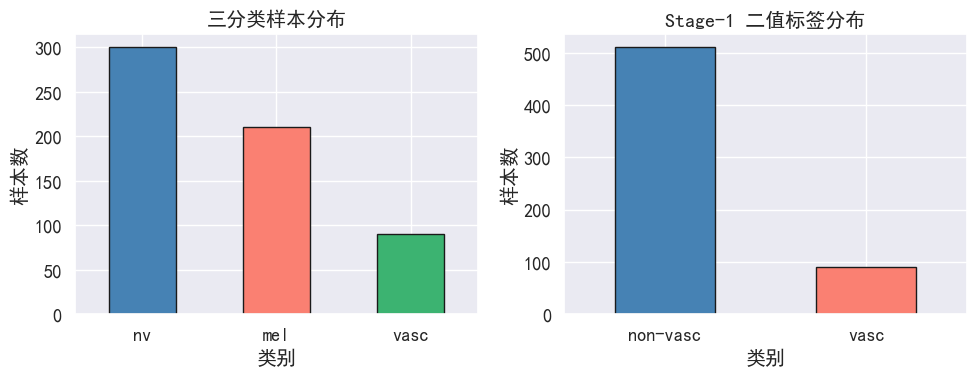

In [2]:
# --- 读取标签 ---
df_label = pd.read_csv(LABEL_CSV)
df_label['image_id'] = df_label['image_id'].astype(str)
label_map = dict(zip(df_label['image_id'], df_label['dx']))

# --- 枚举所有图像，解析 image_id ---
records = []
for img_path in sorted(IMAGE_DIR.glob('*.jpg')):
    stem = img_path.stem                         # e.g. '100_aug1' or '1'
    base_id = re.split(r'_aug', stem)[0]         # strip _aug1/_aug2
    if base_id not in label_map:
        continue
    dx = label_map[base_id]
    mask_path = MASK_DIR / f'mask_{stem}.jpg'
    records.append({
        'stem': stem,
        'base_id': base_id,
        'img_path': img_path,
        'mask_path': mask_path,
        'dx': dx,
        'label': 1 if dx == 'vasc' else 0   # Stage-1 binary label
    })

df_meta = pd.DataFrame(records)
print(f'共 {len(df_meta)} 个样本（含增强）')
print('\n原始标签分布:')
print(df_meta['dx'].value_counts())
print('\n二值标签分布 (1=vasc, 0=non-vasc):')
print(df_meta['label'].value_counts())

# --- 可视化类别分布 ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_meta['dx'].value_counts().plot.bar(ax=axes[0], color=['steelblue','salmon','mediumseagreen'], edgecolor='k')
axes[0].set_title('三分类样本分布'); axes[0].set_xlabel('类别'); axes[0].set_ylabel('样本数'); axes[0].tick_params(rotation=0)

df_meta['label'].value_counts().rename({0:'non-vasc',1:'vasc'}).plot.bar(
    ax=axes[1], color=['steelblue','salmon'], edgecolor='k')
axes[1].set_title('Stage-1 二值标签分布'); axes[1].set_xlabel('类别'); axes[1].set_ylabel('样本数'); axes[1].tick_params(rotation=0)
plt.tight_layout(); plt.show()

## 第二节：多维度特征提取

> 目前这个提取的函数，只提取了下面的几类特征


**1. 输入一张皮肤镜图像和对应掩码，输出一个特征字典**


**2. 颜色统计特征**

对 RGB、HSV、Lab 每个通道分别计算：

- `*_mean`：病灶区域该通道的平均强度，描述整体颜色水平。
- `*_std`：标准差，描述颜色是否均匀。
- `*_skew`：偏度，描述颜色分布是否向高值或低值偏斜。
- `*_kurt`：峰度，描述颜色分布是否尖锐、是否存在极端值。

这些特征对 vasc 很重要，因为血管瘤通常有明显红、蓝、紫等血管相关颜色，而 nv/mel 的色彩分布可能更偏棕黑或更分散。

**3. 颜色比例特征**

- `red_ratio`、`green_ratio`、`blue_ratio`：病灶像素中 R/G/B 在总 RGB 中的平均占比，衡量相对颜色成分。
- `orange_pixel_ratio`：统计满足 `R > 150` 且 `R > G > B` 的橙红色像素比例，用于捕捉鲜红或橙红色血管性区域。
- `blue_purple_ratio`：统计 `B` 高于 `R` 或 `G` 的像素比例，用于捕捉蓝紫色倾向。

**4. 病灶与背景对比**

- `contrast_R/G/B` 是病灶区域和周围皮肤区域的通道均值差的绝对值。
- 如果 vasc 与周围皮肤颜色反差明显，这些特征会更高。

**5. GLCM 纹理特征**

代码先把灰度图中非病灶区域置零，再把灰度量化到 8 个等级，然后计算灰度共生矩阵。

- `glcm_contrast`：局部灰度变化强度，越高说明纹理/边界变化越强。
- `glcm_correlation`：邻近像素灰度相关性。
- `glcm_energy`：纹理重复性或规则性，越高表示灰度组合更集中。
- `glcm_homogeneity`：同质性，越高表示邻近像素更相似。

**6. LBP 纹理特征**

LBP 描述每个像素周围的局部明暗模式。

- `lbp_mean`、`lbp_std` 总结局部纹理编码的平均水平和离散程度。
- `lbp_hist_0` 到 `lbp_hist_9` 是 LBP 编码直方图，描述不同微观纹理模式的占比。

**7. 形状特征**

形状特征来自分割掩码的最大连通区域。

- `lesion_area_ratio`：病灶面积占整图比例。
- `circularity`：圆形度，越接近 1 越接近圆。
- `eccentricity`：离心率，越高越狭长。
- `solidity`：实心度，面积 / 凸包面积，越低说明边界凹陷或不规则更多。
- `extent`：面积 / 外接矩形面积，衡量病灶填满外接框的程度。
- `aspect_ratio`：长轴 / 短轴，衡量拉伸程度。
- `compactness`：紧凑度，与圆形度近似互为反向关系，越大通常越不紧凑。


In [3]:
def extract_features(img_path, mask_path):
    """返回一个特征字典"""
    feats = {}

    # --- 读取图像和掩码 ---
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)

    mask_raw = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) if mask_path.exists() else None
    if mask_raw is not None:
        # 调整掩码尺寸与图像一致
        if mask_raw.shape[:2] != img_rgb.shape[:2]:
            mask_raw = cv2.resize(mask_raw, (img_rgb.shape[1], img_rgb.shape[0]))
        mask = (mask_raw > 127).astype(np.uint8)
    else:
        mask = np.ones(img_rgb.shape[:2], dtype=np.uint8)

    lesion_pixels = mask == 1
    skin_pixels   = mask == 0
    total_pixels  = mask.size

    # ---- 颜色统计特征 ----
    def channel_stats(ch_img, ch_name, px_mask):
        vals = ch_img[px_mask].astype(float)
        if len(vals) == 0:
            vals = ch_img.flatten().astype(float)
        return {
            f'{ch_name}_mean': vals.mean(),
            f'{ch_name}_std':  vals.std(),
            f'{ch_name}_skew': float(stats.skew(vals)),
            f'{ch_name}_kurt': float(stats.kurtosis(vals)),
        }

    for i, name in enumerate(['R','G','B']):
        feats.update(channel_stats(img_rgb[:,:,i], name, lesion_pixels))
    for i, name in enumerate(['H','S','V']):
        feats.update(channel_stats(img_hsv[:,:,i], name, lesion_pixels))
    for i, name in enumerate(['L','A','B_lab']):
        feats.update(channel_stats(img_lab[:,:,i], name, lesion_pixels))

    # ---- 颜色比例特征（红橙偏色） ----
    r, g, b = img_rgb[:,:,0][lesion_pixels], img_rgb[:,:,1][lesion_pixels], img_rgb[:,:,2][lesion_pixels]
    eps = 1e-6
    sum_rgb = r.astype(float) + g + b + eps
    feats['red_ratio']   = float((r / sum_rgb).mean())
    feats['green_ratio'] = float((g / sum_rgb).mean())
    feats['blue_ratio']  = float((b / sum_rgb).mean())
    # 橙红色：R>G>B 且 R高
    feats['orange_pixel_ratio'] = float(((r > 150) & (r > g) & (g > b)).sum() / (lesion_pixels.sum() + 1))
    # 蓝紫色：B相对高
    feats['blue_purple_ratio']  = float(((b > r) | (b > g)).sum() / (lesion_pixels.sum() + 1))

    # ---- 病变 vs. 皮肤颜色对比 ----
    for i, name in enumerate(['R','G','B']):
        l_mean = img_rgb[:,:,i][lesion_pixels].mean() if lesion_pixels.sum() > 0 else 0
        s_mean = img_rgb[:,:,i][skin_pixels].mean()   if skin_pixels.sum()   > 0 else 0
        feats[f'contrast_{name}'] = abs(float(l_mean) - float(s_mean))

    # ---- GLCM 纹理特征 ----
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # 仅在病变区域内计算，裁剪最小外接矩形
    gray_region = gray.copy()
    gray_region[~lesion_pixels] = 0
    gray8 = (gray_region // 32).astype(np.uint8)   # 量化到 8 级减少计算量
    glcm = graycomatrix(gray8, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=8, symmetric=True, normed=True)
    for prop in ['contrast', 'correlation', 'energy', 'homogeneity']:
        val = graycoprops(glcm, prop).mean()
        feats[f'glcm_{prop}'] = float(val)

    # ---- LBP 纹理特征 ----
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_vals = lbp[lesion_pixels]
    feats['lbp_mean'] = float(lbp_vals.mean()) if len(lbp_vals) > 0 else 0.0
    feats['lbp_std']  = float(lbp_vals.std())  if len(lbp_vals) > 0 else 0.0
    hist, _ = np.histogram(lbp_vals, bins=10, range=(0, 10), density=True)
    for idx, v in enumerate(hist):
        feats[f'lbp_hist_{idx}'] = float(v)

    # ---- 形状特征（来自掩码） ----
    area = float(lesion_pixels.sum())
    feats['lesion_area_ratio'] = area / total_pixels

    labeled = sk_label(mask)
    props = regionprops(labeled)
    if props:
        # 选最大连通区域
        rp = max(props, key=lambda p: p.area)
        perim = rp.perimeter if rp.perimeter > 0 else 1
        feats['circularity']    = float(4 * np.pi * rp.area / (perim ** 2))
        feats['eccentricity']   = float(rp.eccentricity)
        feats['solidity']       = float(rp.solidity)
        feats['extent']         = float(rp.extent)
        ax_minor = rp.minor_axis_length if rp.minor_axis_length > 0 else 1
        feats['aspect_ratio']   = float(rp.major_axis_length / ax_minor)
        feats['compactness']    = float(perim ** 2 / (4 * np.pi * rp.area)) if rp.area > 0 else 0
    else:
        for k in ['circularity','eccentricity','solidity','extent','aspect_ratio','compactness']:
            feats[k] = 0.0

    return feats

print('特征提取函数已定义，开始提取...')

特征提取函数已定义，开始提取...


### 批量提取全部样本的以上特征

这个单元遍历 `df_meta` 中的 600 个样本，对每张图调用 `extract_features`。

- `all_feats` 保存每张图得到的特征字典。
- `valid_idx` 保存成功提取特征的样本索引，用来同步过滤元数据。
- `df_feat` 是最终特征矩阵：每行一个样本，每列一个特征。
- `labels` 是与 `df_feat` 行顺序一致的二分类标签。


In [4]:
# --- 批量提取 ---
all_feats = []
valid_idx = []

for i, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc='Extracting features'):
    feats = extract_features(row['img_path'], row['mask_path'])
    if feats is not None:
        all_feats.append(feats)
        valid_idx.append(i)

df_feat = pd.DataFrame(all_feats)
df_meta_valid = df_meta.loc[valid_idx].reset_index(drop=True)
df_feat.index = df_meta_valid.index

feature_names = df_feat.columns.tolist()
labels = df_meta_valid['label'].values

print(f'\n成功提取 {len(df_feat)} 个样本，共 {len(feature_names)} 个特征')
print(f'特征维度: {df_feat.shape}')


Extracting features:   0%|          | 0/600 [00:00<?, ?it/s]


成功提取 600 个样本，共 67 个特征
特征维度: (600, 67)


## 第三节：特征质量评估：单变量评估
> 也就是 独立看每一个特征 ， 使用以下五类互补指标对每个特征的区分能力进行量化评估：

| 指标 | 全称 | 含义 |
|------|------|------|
| **F-score** | ANOVA F统计量 | 组间方差 / 组内方差，值越大类间差异越显著 |
| **MI** | 互信息 | 特征与标签的信息共享量，非线性相关度量 |
| **AUC** | ROC曲线下面积 | 单特征阈值分类能力，0.5=无效，1.0=完美 |
| **Cohen's d** | 效应量 | 标准化均值差，衡量实际区分效果大小 |
| **p-value** | Mann-Whitney U检验 p值 | 非参数显著性检验，不依赖正态假设 |
| **KS统计量** | Kolmogorov-Smirnov | 两类分布最大差异，对分布形状差异敏感 |

### (1) 计算综合排名

`compute_feature_metrics(df_feat, labels)` 对每一列特征计算多个互补指标，然后生成综合排名。

**综合得分逻辑**

先把 `pvalue` 转成 `-log10(p)`，这样 p 值越小得分越高；再把 `F_score`、`MI`、`AUC`、`Cohens_d`、`KS_stat`、`-log10(p)` 统一归一化到 0-1，最后取平均得到 `composite_score`。就是把显著性、分类能力、效应大小和分布差异合在一起排序。

**现在是取综合排名前二十的，这个数字可以改**

In [5]:
def compute_feature_metrics(df_feat, labels):
    """计算所有特征的多指标质量评分，返回 DataFrame"""
    X = df_feat.values
    y = labels
    X_clean = np.nan_to_num(X)

    # --- F-score (ANOVA) ---
    f_vals, f_pvals = f_classif(X_clean, y)

    # --- 互信息 ---
    mi_vals = mutual_info_classif(X_clean, y, random_state=42)

    rows = []
    vasc_idx    = y == 1
    nonvasc_idx = y == 0

    for j, feat in enumerate(df_feat.columns):
        v0 = X_clean[nonvasc_idx, j]
        v1 = X_clean[vasc_idx, j]

        # AUC（对每个特征做单特征打分）
        try:
            auc = roc_auc_score(y, X_clean[:, j])
            auc = max(auc, 1 - auc)   # 方向无关，取>0.5侧
        except Exception:
            auc = 0.5

        # Cohen's d
        pooled_std = np.sqrt((v0.std()**2 + v1.std()**2) / 2)
        cohens_d   = abs(v1.mean() - v0.mean()) / (pooled_std + 1e-9)

        # Mann-Whitney U
        try:
            _, mw_p = mannwhitneyu(v0, v1, alternative='two-sided')
        except Exception:
            mw_p = 1.0

        # KS 统计量
        try:
            ks_stat, _ = ks_2samp(v0, v1)
        except Exception:
            ks_stat = 0.0

        rows.append({
            'feature':   feat,
            'F_score':   f_vals[j],
            'F_pvalue':  f_pvals[j],
            'MI':        mi_vals[j],
            'AUC':       auc,
            'Cohens_d':  cohens_d,
            'MW_pvalue': mw_p,
            'KS_stat':   ks_stat,
            'vasc_mean':    v1.mean(),
            'nonvasc_mean': v0.mean(),
        })

    df_scores = pd.DataFrame(rows)

    # --- 综合排名：对各指标归一化后取平均（p值取负log处理方向） ---
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    df_scores['neg_log_MWp'] = -np.log10(df_scores['MW_pvalue'] + 1e-300)
    rank_cols = ['F_score', 'MI', 'AUC', 'Cohens_d', 'KS_stat', 'neg_log_MWp']
    normed = scaler.fit_transform(df_scores[rank_cols])
    df_scores['composite_score'] = normed.mean(axis=1)
    df_scores = df_scores.sort_values('composite_score', ascending=False).reset_index(drop=True)

    return df_scores


df_scores = compute_feature_metrics(df_feat, labels)
print('Top-20 特征（按综合得分排名）:')
display_cols = ['feature','F_score','MI','AUC','Cohens_d','KS_stat','MW_pvalue','composite_score']
df_scores[display_cols].head(20).style.background_gradient(cmap='YlOrRd', subset=['composite_score','AUC','Cohens_d'])

Top-20 特征（按综合得分排名）:


,feature,F_score,MI,AUC,Cohens_d,KS_stat,MW_pvalue,composite_score
0,blue_purple_ratio,207.494322,0.239785,0.921176,2.112832,0.813072,0.000000,0.958011
1,H_mean,193.782876,0.218381,0.902113,2.012531,0.741176,0.000000,0.888689
2,green_ratio,257.909682,0.177832,0.855338,1.457289,0.595425,0.000000,0.772784
3,A_mean,268.592327,0.245796,0.781678,1.321787,0.634641,0.000000,0.751347
4,orange_pixel_ratio,92.531561,0.170797,0.886536,1.408276,0.679739,0.000000,0.715505
5,B_lab_mean,168.539593,0.162051,0.844270,1.432767,0.538562,0.000000,0.680244
6,blue_ratio,149.541847,0.128771,0.841220,1.402595,0.527451,0.000000,0.637839
7,H_std,110.969345,0.167627,0.819390,1.407414,0.595425,0.000000,0.634207
8,B_std,124.790114,0.126200,0.813007,1.278297,0.567974,0.000000,0.591967
9,solidity,54.698456,0.122630,0.803464,1.065188,0.482353,0.000000,0.500473


### (1.1) 多重比较校正：FDR 校正

上一步对所有特征都做了 Mann-Whitney U 检验。由于一次性检验了几十个特征，如果只看原始 `p-value`，会增加假阳性风险。因此这里加入 Benjamini-Hochberg FDR 校正。

本单元新增三列：

- `MW_pvalue_FDR`：Mann-Whitney U 检验 p 值经过 FDR 校正后的结果；
- `FDR_significant`：在 `alpha=0.05` 下是否仍然显著；
- `is_strong_univariate`：一个更严格的初筛标记，要求同时满足 `AUC >= 0.70`、`Cohen's d >= 0.8` 和 FDR 显著。

这一步的意义是：最终不要只依赖“综合分排名”，还要确认特征的统计显著性和实际效应量是否足够稳定。

In [6]:
def bh_fdr_correction(pvalues, alpha=0.05):
    """Benjamini-Hochberg FDR correction.

    返回：
    - adjusted_pvalues: FDR 校正后的 p 值
    - reject: 是否在给定 alpha 下拒绝原假设
    """
    pvalues = np.asarray(pvalues, dtype=float)
    n = len(pvalues)
    order = np.argsort(pvalues)
    ranked_p = pvalues[order]

    adjusted = ranked_p * n / (np.arange(1, n + 1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    adjusted_pvalues = np.empty_like(adjusted)
    adjusted_pvalues[order] = adjusted
    reject = adjusted_pvalues <= alpha
    return adjusted_pvalues, reject

# 对 Mann-Whitney U 检验 p 值做 FDR 校正
df_scores['MW_pvalue_FDR'], df_scores['FDR_significant'] = bh_fdr_correction(
    df_scores['MW_pvalue'].values,
    alpha=0.05
)

# 更严格的单变量强特征筛选条件，可根据任务需要调整阈值
df_scores['is_strong_univariate'] = (
    (df_scores['AUC'] >= 0.70) &
    (df_scores['Cohens_d'] >= 0.80) &
    (df_scores['FDR_significant'])
)

display_cols_fdr = [
    'feature', 'AUC', 'Cohens_d', 'KS_stat',
    'MW_pvalue', 'MW_pvalue_FDR', 'FDR_significant',
    'is_strong_univariate', 'composite_score'
]

print('FDR 校正后 Top-20 特征：')
display(
    df_scores[display_cols_fdr]
    .head(20)
    .style.background_gradient(cmap='YlOrRd', subset=['AUC', 'Cohens_d', 'KS_stat', 'composite_score'])
)

print('\n满足 AUC >= 0.70、Cohen\'s d >= 0.8 且 FDR 显著的特征数：',
      int(df_scores['is_strong_univariate'].sum()))

FDR 校正后 Top-20 特征：


,feature,AUC,Cohens_d,KS_stat,MW_pvalue,MW_pvalue_FDR,FDR_significant,is_strong_univariate,composite_score
0,blue_purple_ratio,0.921176,2.112832,0.813072,0.000000,0.000000,True,True,0.958011
1,H_mean,0.902113,2.012531,0.741176,0.000000,0.000000,True,True,0.888689
2,green_ratio,0.855338,1.457289,0.595425,0.000000,0.000000,True,True,0.772784
3,A_mean,0.781678,1.321787,0.634641,0.000000,0.000000,True,True,0.751347
4,orange_pixel_ratio,0.886536,1.408276,0.679739,0.000000,0.000000,True,True,0.715505
5,B_lab_mean,0.844270,1.432767,0.538562,0.000000,0.000000,True,True,0.680244
6,blue_ratio,0.841220,1.402595,0.527451,0.000000,0.000000,True,True,0.637839
7,H_std,0.819390,1.407414,0.595425,0.000000,0.000000,True,True,0.634207
8,B_std,0.813007,1.278297,0.567974,0.000000,0.000000,True,True,0.591967
9,solidity,0.803464,1.065188,0.482353,0.000000,0.000000,True,True,0.500473



满足 AUC >= 0.70、Cohen's d >= 0.8 且 FDR 显著的特征数： 21


### (2) 可视化--条形图
- 展示综合得分、每个指标的单独得分。
- 防止单纯依赖综合分，因为综合分可能掩盖不同指标之间的差异。

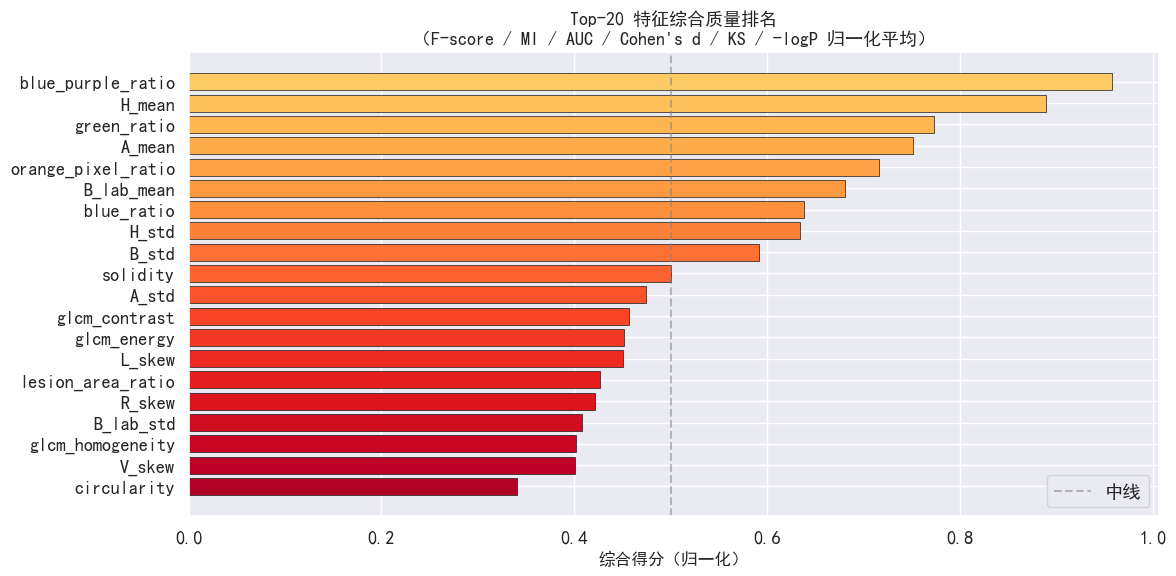

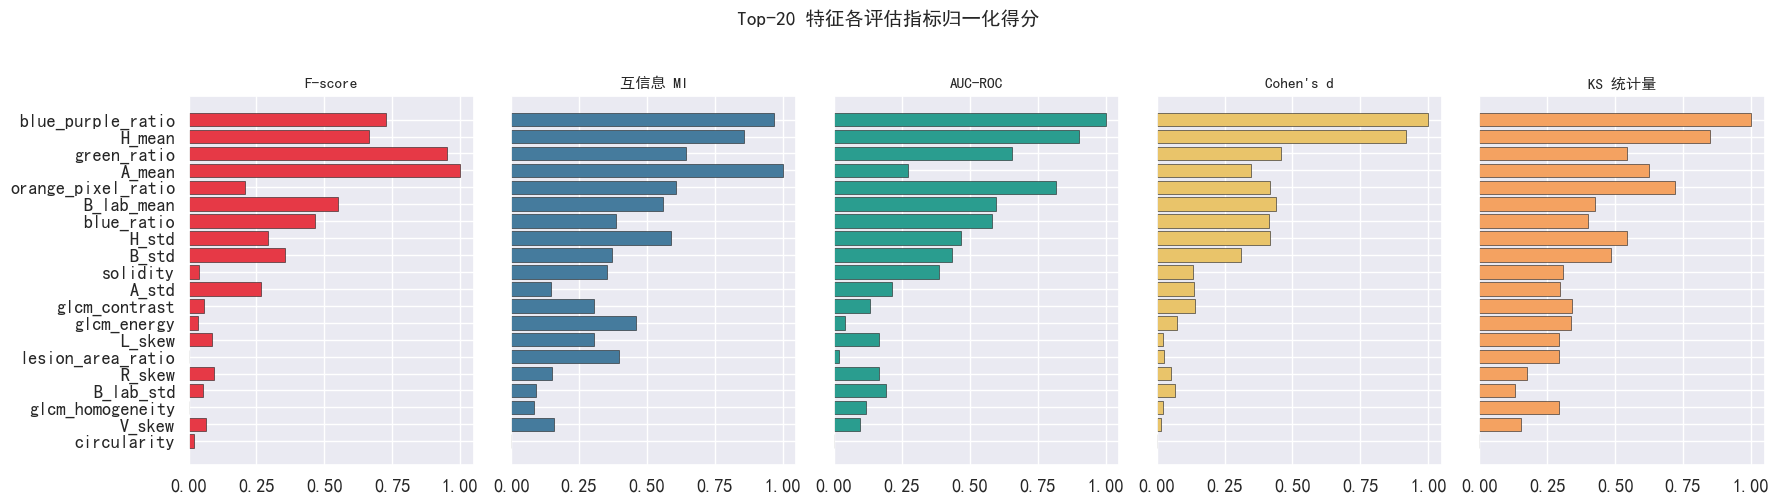

In [12]:

# ---- 4.1 Top-20 特征综合得分条形图 ----
top20 = df_scores.head(20)
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top20)))
bars = ax.barh(top20['feature'][::-1], top20['composite_score'][::-1], color=colors[::-1], edgecolor='k', linewidth=0.5)
ax.set_xlabel('综合得分（归一化）', fontsize=12)
ax.set_title('Top-20 特征综合质量排名\n（F-score / MI / AUC / Cohen\'s d / KS / -logP 归一化平均）', fontsize=13)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='中线')
ax.legend(); plt.tight_layout(); plt.show()

# ---- 4.2 多指标并排条形图 ----
metrics = ['F_score', 'MI', 'AUC', 'Cohens_d', 'KS_stat']
metric_labels = ['F-score', '互信息 MI', 'AUC-ROC', "Cohen's d", 'KS 统计量']

from sklearn.preprocessing import MinMaxScaler
normed_top20 = MinMaxScaler().fit_transform(top20[metrics])

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5), sharey=True)
palette = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261']
for ax, col, label, color, vals in zip(axes, metrics, metric_labels, palette, normed_top20.T):
    ax.barh(top20['feature'][::-1], vals[::-1], color=color, edgecolor='k', linewidth=0.4)
    ax.set_title(label, fontsize=11)
    ax.set_xlim(0, 1.05)

fig.suptitle('Top-20 特征各评估指标归一化得分', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### (2) 可视化--AUC 与 Cohen's d 散点图

这张散点图同时展示每个特征的“分类能力”和“效应大小”。

- 横轴 `Cohen's d`：两类均值差异相对于组内波动的大小。
- 纵轴 `AUC`：单特征阈值分类能力。
- 颜色表示综合得分，颜色越深通常综合质量越高。
- 横向虚线 `AUC=0.7` 表示较有实用价值的单特征分类能力参考线。
- 纵向虚线 `d=0.8` 表示大效应量参考线。

右上角区域的特征最理想：均值差异大，同时单独做分类也有较强区分能力。


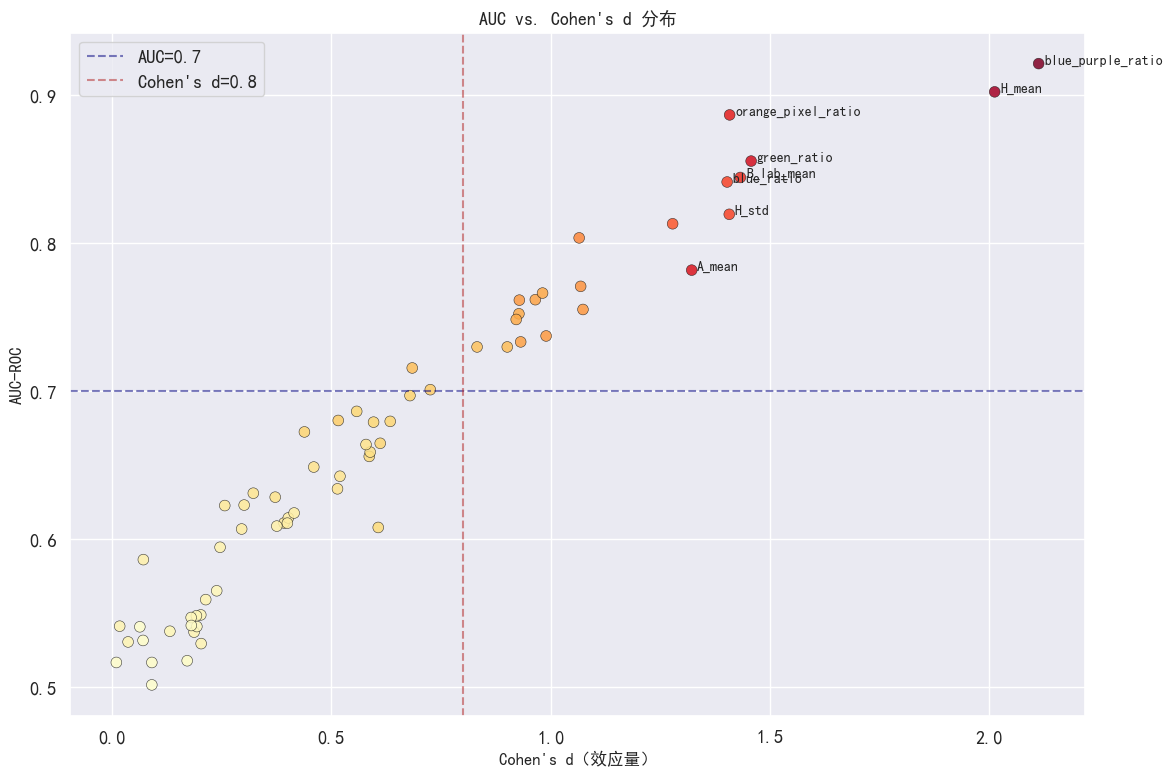

In [7]:
# ---- 4.3 AUC vs. Cohen's d 散点图（全特征） ----
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(df_scores['Cohens_d'], df_scores['AUC'],
                c=df_scores['composite_score'], cmap='YlOrRd', s=60, edgecolors='k', linewidths=0.4, alpha=0.85)
ax.axhline(0.7, color='navy', linestyle='--', alpha=0.5, label='AUC=0.7')
ax.axvline(0.8, color='firebrick', linestyle='--', alpha=0.5, label="Cohen's d=0.8")
ax.set_xlabel("Cohen's d（效应量）", fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('AUC vs. Cohen\'s d 分布', fontsize=13)
# 标注 Top-8
for _, row in df_scores.head(8).iterrows():
    ax.annotate(row['feature'], (row['Cohens_d'], row['AUC']),
                fontsize=10, xytext=(4, 0), textcoords='offset points')
ax.legend(); plt.tight_layout(); plt.show()

### (3) 可视化--箱式图

这组 12 个子图比较 Top-12 特征在 `vasc` 和 `non-vasc` 两类中的取值分布。

- 箱线图显示中位数、四分位数和离群点。
- 叠加的散点显示每个样本的实际取值，能观察类别内部离散程度和样本重叠。
- 每个小标题列出该特征的 `AUC`、`Cohen's d` 和 `MW_pvalue`。

如果两类箱体明显分离、散点重叠少，说明这个特征对分类更有帮助。如果箱体重叠严重，即使 p 值显著，也可能只是样本量导致的统计显著，实际分类价值有限。


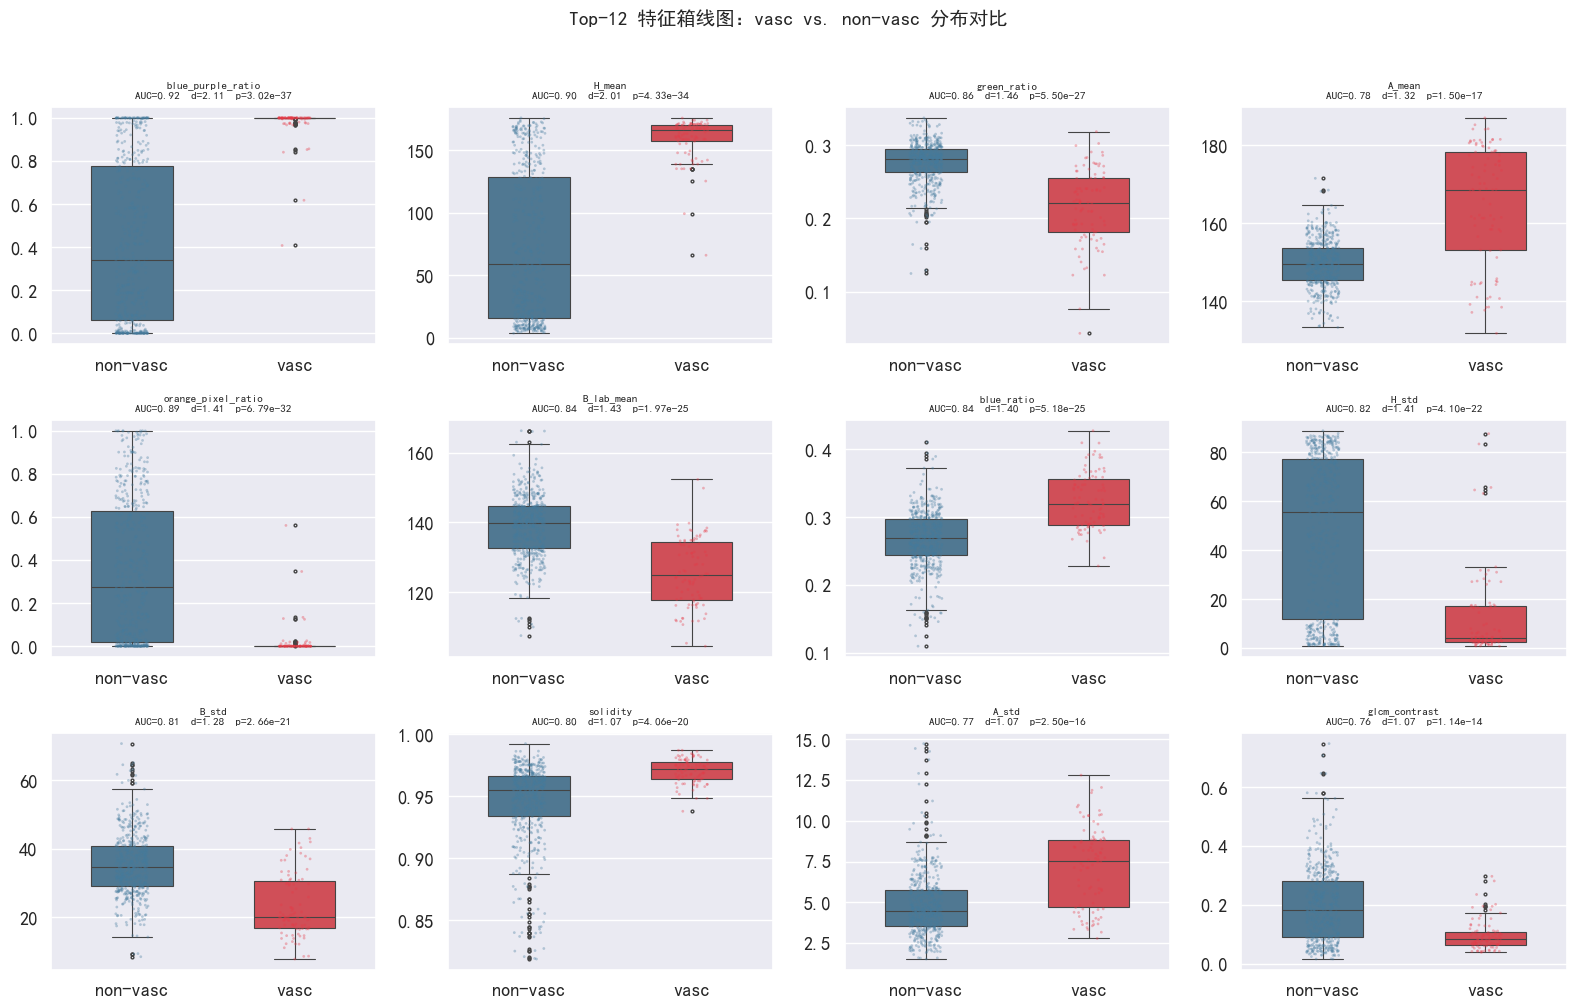

In [8]:
# ---- 4.4 Top-12 特征的箱线图：vasc vs. non-vasc 分布对比 ----
top12_feats = df_scores.head(12)['feature'].tolist()
df_plot = df_feat[top12_feats].copy()
df_plot['class'] = pd.Series(labels, index=df_feat.index).map({0:'non-vasc', 1:'vasc'})

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
palette_box = {'vasc': '#E63946', 'non-vasc': '#457B9D'}

for ax, feat in zip(axes, top12_feats):
    sns.boxplot(data=df_plot, x='class', y=feat, palette=palette_box, ax=ax,
                width=0.5, linewidth=0.8, fliersize=2)
    # 叠加抖散点
    sns.stripplot(data=df_plot, x='class', y=feat, palette=palette_box, ax=ax,
                  size=2, alpha=0.35, jitter=True)

    row = df_scores[df_scores['feature'] == feat].iloc[0]
    ax.set_title(f'{feat}\nAUC={row["AUC"]:.2f}  d={row["Cohens_d"]:.2f}  p={row["MW_pvalue"]:.2e}',
                 fontsize=8)
    ax.set_xlabel(''); ax.set_ylabel('')

fig.suptitle('Top-12 特征箱线图：vasc vs. non-vasc 分布对比', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### (4) 可视化--KDE 密度分布对比

KDE 图展示 Top-6 特征在两类样本中的平滑概率密度。

- 蓝色区域是 `non-vasc`，红色区域是 `vasc`。
- 曲线峰值的位置表示该类样本常见的取值范围。
- 两条曲线分离越明显，特征越容易用阈值区分两类。
- 标题中的 `AUC` 反映单特征分类能力，`KS` 反映两类整体分布差异。

相比箱线图，KDE 更容易看出分布是否多峰、是否存在长尾，以及两类重叠主要发生在哪个取值区间。


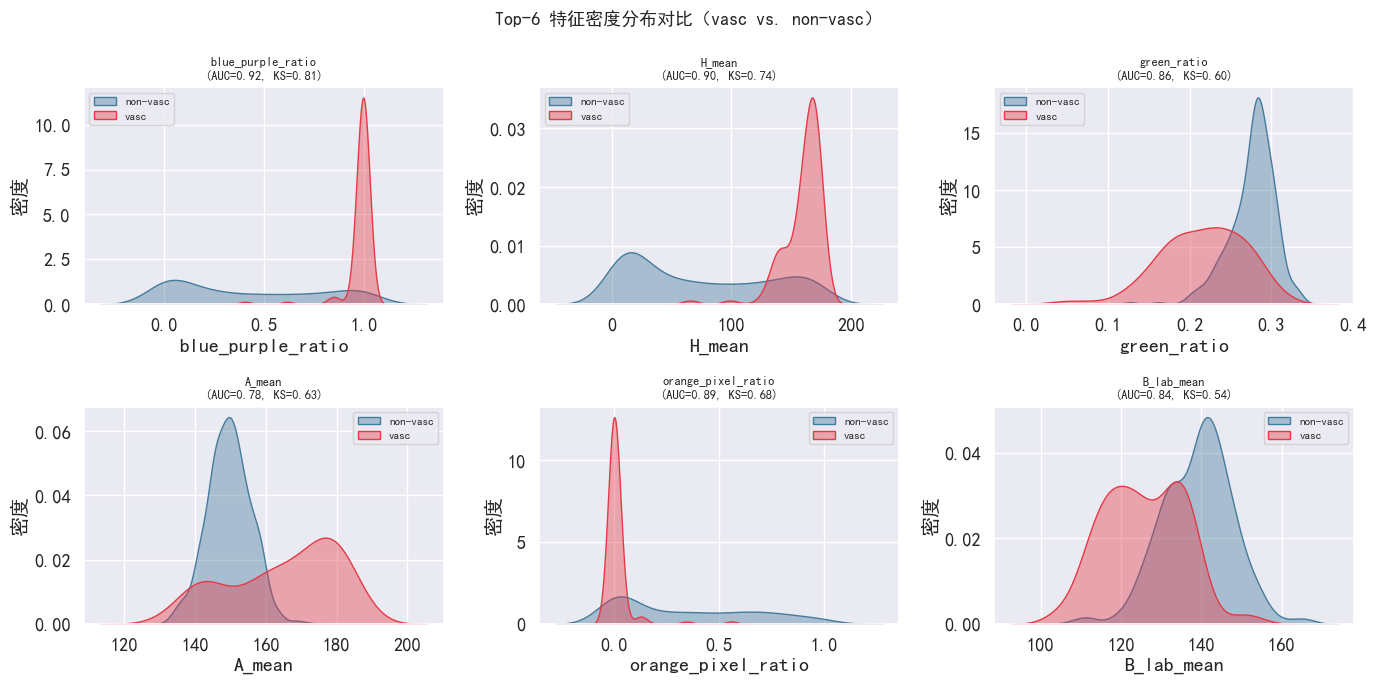

In [10]:
# ---- 4.5 Top-6 特征 KDE 密度对比图 ----
top6 = df_scores.head(6)['feature'].tolist()
vasc_data    = df_feat[labels == 1]
nonvasc_data = df_feat[labels == 0]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for ax, feat in zip(axes, top6):
    sns.kdeplot(nonvasc_data[feat], ax=ax, label='non-vasc', color='#457B9D', fill=True, alpha=0.4)
    sns.kdeplot(vasc_data[feat],    ax=ax, label='vasc',     color='#E63946', fill=True, alpha=0.4)
    row = df_scores[df_scores['feature'] == feat].iloc[0]
    ax.set_title(f'{feat}\n(AUC={row["AUC"]:.2f}, KS={row["KS_stat"]:.2f})', fontsize=9)
    ax.legend(fontsize=8); ax.set_ylabel('密度')

fig.suptitle('Top-6 特征密度分布对比（vasc vs. non-vasc）', fontsize=13)
plt.tight_layout(); plt.show()

## 第四节： 多变量评估--相关性分析

### （1） 特征相关性热力图

Pearson 相关系数，用于判断冗余。

- 数值接近 `1` 表示两个特征高度正相关，可能表达相似信息。
- 数值接近 `-1` 表示高度负相关，也可能存在冗余。
- 数值接近 `0` 表示线性相关弱。
- 代码只显示下三角矩阵，避免重复。

这个图的核心用途是特征筛选：如果两个高分特征相关系数超过 0.9，通常可以保留综合分更高或更易解释的一个，减少模型冗余和过拟合风险。



前面的 Pearson 相关性主要反映线性关系。但图像特征经常存在偏态分布、长尾分布或非线性单调关系，因此这里补充 Spearman 相关性。

筛选冗余特征时，建议同时参考：

- `abs(Pearson) > 0.90`：线性高度相关；
- `abs(Spearman) > 0.90`：单调高度相关。

如果两个特征高度相关，一般保留综合得分更高、可解释性更强或与病理视觉特征更一致的一个。

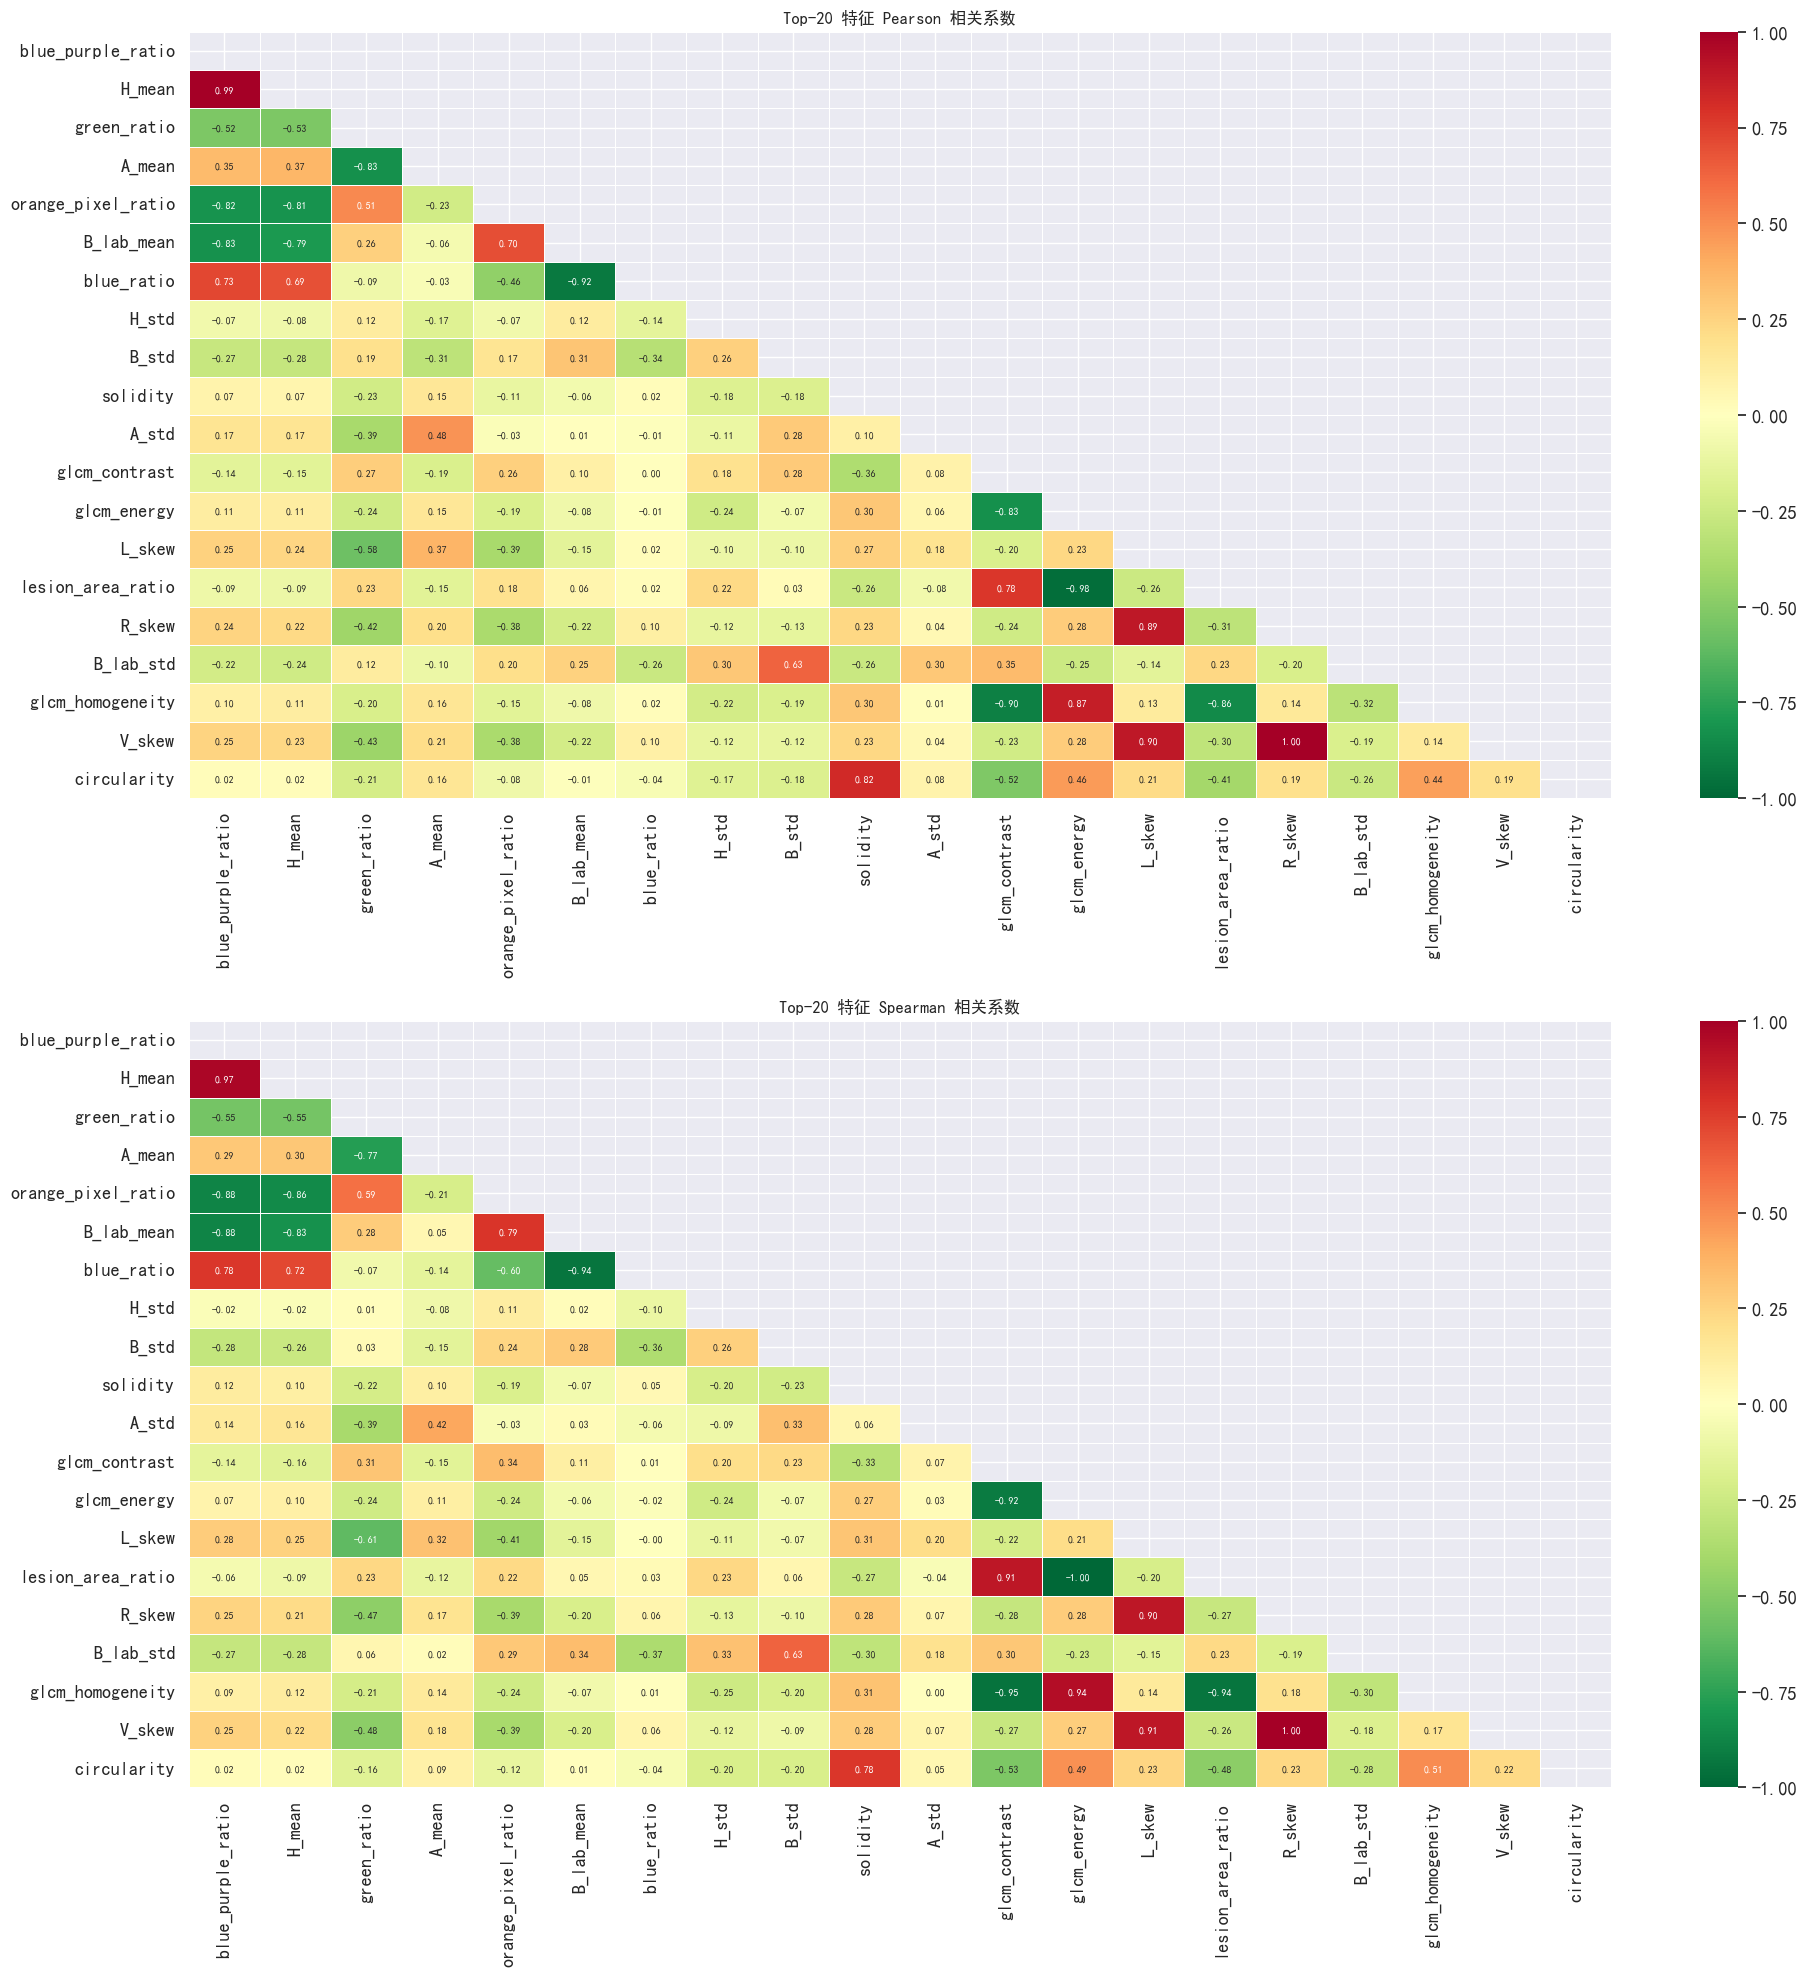

Pearson |r| >= 0.90 的高相关特征对：


,feature_1,feature_2,corr,abs_corr
0,R_skew,V_skew,0.997573,0.997573
1,blue_purple_ratio,H_mean,0.994076,0.994076
2,glcm_energy,lesion_area_ratio,-0.976033,0.976033
3,B_lab_mean,blue_ratio,-0.924955,0.924955



Spearman |rho| >= 0.90 的高相关特征对：


,feature_1,feature_2,corr,abs_corr
0,R_skew,V_skew,0.997238,0.997238
1,glcm_energy,lesion_area_ratio,-0.996309,0.996309
2,blue_purple_ratio,H_mean,0.970244,0.970244
3,glcm_contrast,glcm_homogeneity,-0.945534,0.945534
4,glcm_energy,glcm_homogeneity,0.942362,0.942362
5,B_lab_mean,blue_ratio,-0.940275,0.940275
6,lesion_area_ratio,glcm_homogeneity,-0.939539,0.939539
7,glcm_contrast,glcm_energy,-0.915086,0.915086
8,L_skew,V_skew,0.905738,0.905738
9,glcm_contrast,lesion_area_ratio,0.905535,0.905535


In [13]:
# ---- Pearson + Spearman 相关性联合分析 ----
top20_feats = df_scores.head(20)['feature'].tolist()

corr_pearson = df_feat[top20_feats].corr(method='pearson')
corr_spearman = df_feat[top20_feats].corr(method='spearman')

fig, axes = plt.subplots(2, 1, figsize=(20, 20))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=axes[0], annot_kws={'size': 7},
            vmin=-1, vmax=1)
axes[0].set_title('Top-20 特征 Pearson 相关系数', fontsize=12)

sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=axes[1], annot_kws={'size': 7},
            vmin=-1, vmax=1)
axes[1].set_title('Top-20 特征 Spearman 相关系数', fontsize=12)

plt.tight_layout()
plt.show()


def list_high_corr_pairs(corr_matrix, threshold=0.90):
    """列出相关矩阵中绝对相关系数超过阈值的特征对。"""
    pairs = []
    cols = corr_matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append({
                    'feature_1': cols[i],
                    'feature_2': cols[j],
                    'corr': r,
                    'abs_corr': abs(r)
                })
    return pd.DataFrame(pairs).sort_values('abs_corr', ascending=False).reset_index(drop=True)

pearson_high = list_high_corr_pairs(corr_pearson, threshold=0.90)
spearman_high = list_high_corr_pairs(corr_spearman, threshold=0.90)

print('Pearson |r| >= 0.90 的高相关特征对：')
display(pearson_high)
print('\nSpearman |rho| >= 0.90 的高相关特征对：')
display(spearman_high)

### （1.2）PCA 可视化：用于辅助理解，不作为最终筛选主依据

PCA 的作用是把多个特征投影到低维空间，观察 `vasc` 和 `non-vasc` 是否在整体特征结构上存在分离趋势。

但是：

1. PCA 是无监督方法，不使用标签，因此不能直接代表分类效果；
2. PCA 得到的是主成分，不是原始特征，解释性弱于原始颜色/纹理/形状特征；
3. 所以 PCA 只作为可视化和冗余诊断，不作为最终筛选主方法。


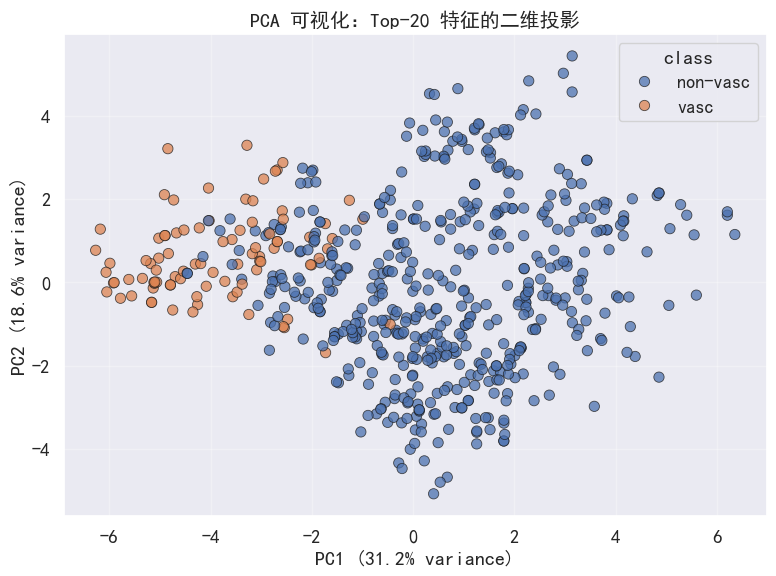

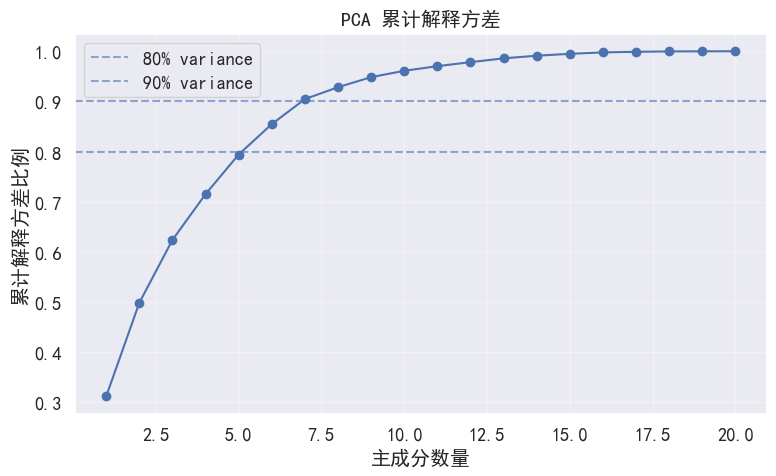

PC1 贡献最大的 Top-10 原始特征：


,PC1_loading,PC2_loading,PC1_abs,PC2_abs
orange_pixel_ratio,0.277905,-0.239576,0.277905,0.239576
blue_purple_ratio,-0.276808,0.331410,0.276808,0.331410
H_mean,-0.274967,0.322825,0.274967,0.322825
green_ratio,0.273051,-0.072000,0.273051,0.072000
glcm_contrast,0.256400,0.299762,0.256400,0.299762
R_skew,-0.251555,-0.017893,0.251555,0.017893
V_skew,-0.251069,-0.016069,0.251069,0.016069
L_skew,-0.249354,-0.013130,0.249354,0.013130
glcm_energy,-0.248556,-0.325108,0.248556,0.325108
lesion_area_ratio,0.240653,0.320709,0.240653,0.320709



PC2 贡献最大的 Top-10 原始特征：


,PC1_loading,PC2_loading,PC1_abs,PC2_abs
blue_purple_ratio,-0.276808,0.331410,0.276808,0.331410
B_lab_mean,0.236114,-0.325435,0.236114,0.325435
glcm_energy,-0.248556,-0.325108,0.248556,0.325108
blue_ratio,-0.176224,0.323355,0.176224,0.323355
H_mean,-0.274967,0.322825,0.274967,0.322825
lesion_area_ratio,0.240653,0.320709,0.240653,0.320709
glcm_homogeneity,-0.231661,-0.317738,0.231661,0.317738
glcm_contrast,0.256400,0.299762,0.256400,0.299762
circularity,-0.183651,-0.257857,0.183651,0.257857
orange_pixel_ratio,0.277905,-0.239576,0.277905,0.239576


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 使用 Top-20 特征进行 PCA 可视化
pca_feats = df_scores.head(20)['feature'].tolist()
X_pca = df_feat[pca_feats].replace([np.inf, -np.inf], np.nan).fillna(0)
X_scaled = StandardScaler().fit_transform(X_pca)

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    'PC1': X_2d[:, 0],
    'PC2': X_2d[:, 1],
    'class': pd.Series(labels, index=df_feat.index).map({0: 'non-vasc', 1: 'vasc'}),
    'dx': df_meta_valid['dx'].values,
    'base_id': df_meta_valid['base_id'].values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='class',
    alpha=0.75,
    s=55,
    edgecolor='k'
)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% variance)')
plt.title('PCA 可视化：Top-20 特征的二维投影')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 累计解释方差：判断需要多少主成分可以解释大部分特征方差
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.80, linestyle='--', alpha=0.6, label='80% variance')
plt.axhline(0.90, linestyle='--', alpha=0.6, label='90% variance')
plt.xlabel('主成分数量')
plt.ylabel('累计解释方差比例')
plt.title('PCA 累计解释方差')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 查看 PC1 / PC2 主要由哪些原始特征贡献，便于解释 PCA 图
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=pca_feats,
    columns=['PC1_loading', 'PC2_loading']
)
loadings['PC1_abs'] = loadings['PC1_loading'].abs()
loadings['PC2_abs'] = loadings['PC2_loading'].abs()

print('PC1 贡献最大的 Top-10 原始特征：')
display(loadings.sort_values('PC1_abs', ascending=False).head(10))
print('\nPC2 贡献最大的 Top-10 原始特征：')
display(loadings.sort_values('PC2_abs', ascending=False).head(10))

### （2）颜色、纹理、形状三类特征的雷达图

这个单元先用 `get_category` 按特征名前缀把特征分为三类：颜色纹理形状

然后按类别计算五个指标的平均值，并归一化后画成雷达图。

雷达图的意义：

- 哪个类别覆盖面积更大，说明该类别特征整体质量更强。
- 如果“颜色”明显强于其他类别，说明 vasc 与 non-vasc 的差异主要来自颜色。
- 如果“纹理”或“形状”也有较大覆盖面积，说明它们能提供补充信息。


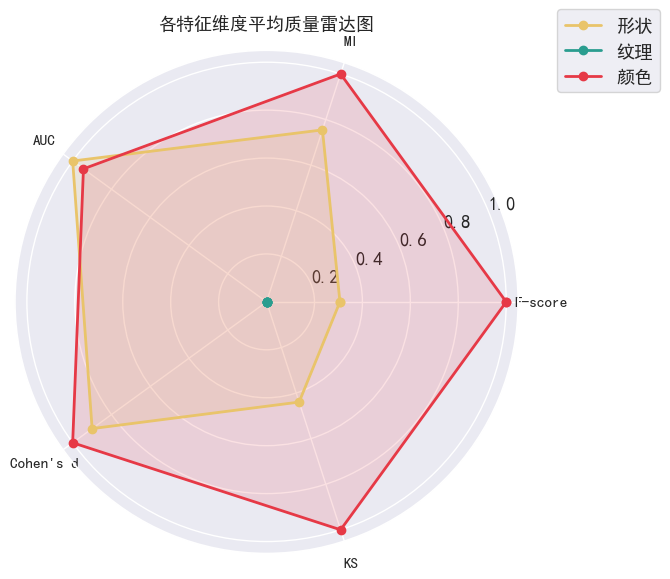


各维度特征数量：
category
颜色    44
纹理    16
形状     7


In [15]:
# ---- 4.7 各维度（颜色/纹理/形状）Top特征得分汇总雷达图 ----
def get_category(feat_name):
    if feat_name.startswith(('R_','G_','B_','H_','S_','V_','L_','A_','B_lab',
                              'red_','green_','blue_','orange_','contrast_','blue_purple')):
        return '颜色'
    elif feat_name.startswith(('glcm_','lbp_')):
        return '纹理'
    else:
        return '形状'

df_scores['category'] = df_scores['feature'].apply(get_category)
cat_summary = df_scores.groupby('category')[['F_score','MI','AUC','Cohens_d','KS_stat']].mean()
cat_normed  = (cat_summary - cat_summary.min()) / (cat_summary.max() - cat_summary.min() + 1e-9)

categories_radar = ['F-score','MI','AUC','Cohen\'s d','KS']
N = len(categories_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={'polar': True})
color_map = {'颜色':'#E63946','纹理':'#2A9D8F','形状':'#E9C46A'}

for cat, row in cat_normed.iterrows():
    vals = row.tolist() + [row.iloc[0]]
    ax.plot(angles, vals, 'o-', linewidth=2, label=cat, color=color_map[cat])
    ax.fill(angles, vals, alpha=0.15, color=color_map[cat])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_radar, fontsize=11)
ax.set_title('各特征维度平均质量雷达图', fontsize=13, pad=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()

print('\n各维度特征数量：')
print(df_scores['category'].value_counts().to_string())

## 第五节：如何确定最终特征和数量？

最终特征数量不建议手动固定成 Top-10 或 Top-20。更合理的方法是把“特征数量”当成一个超参数，比较不同候选数量下的表现。

1. 先按照前面得到的综合得分对特征排序；
2. 依次测试 Top-5、Top-8、Top-10、Top-12、Top-15、Top-20 等候选集合；

```python
# 候选 Top-k 数量
k_list = [5, 8, 10, 12, 15, 20, 25, 30]  #可以修改
```
4. 每个集合内部先做相关性去冗余；
5. 使用 GroupKFold / StratifiedGroupKFold，按 base_id 分组交叉验证；
6. 观察验证集 ROC-AUC、Balanced Accuracy、F1、PR-AUC 随特征数量变化；
7. 选择性能接近最优、但特征数量更少的方案。


交叉验证方式： StratifiedGroupKFold


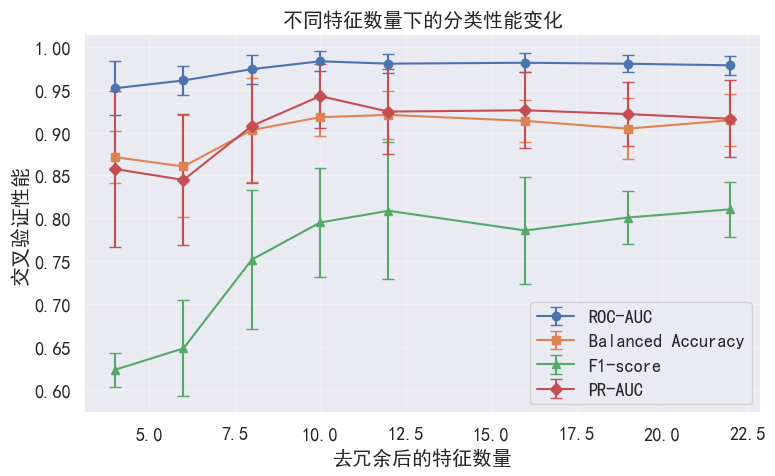

最终特征数量选择结果
最高平均 ROC-AUC：0.9832
允许的 AUC 容忍范围：0.0100
最终选择的去冗余后特征数量：8
该方案平均 ROC-AUC：0.9740 ± 0.0169
该方案 Balanced Accuracy：0.9030 ± 0.0603
该方案 F1-score：0.7519 ± 0.0812
该方案 PR-AUC：0.9078 ± 0.0669

最终确定的特征如下：
01. blue_purple_ratio
02. green_ratio
03. A_mean
04. orange_pixel_ratio
05. B_lab_mean
06. H_std
07. B_std
08. solidity


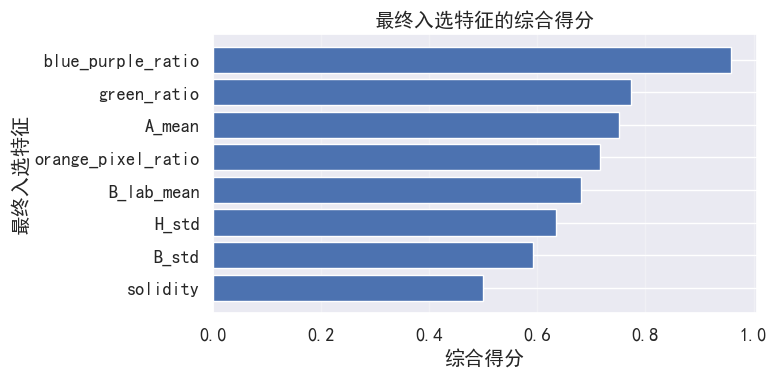

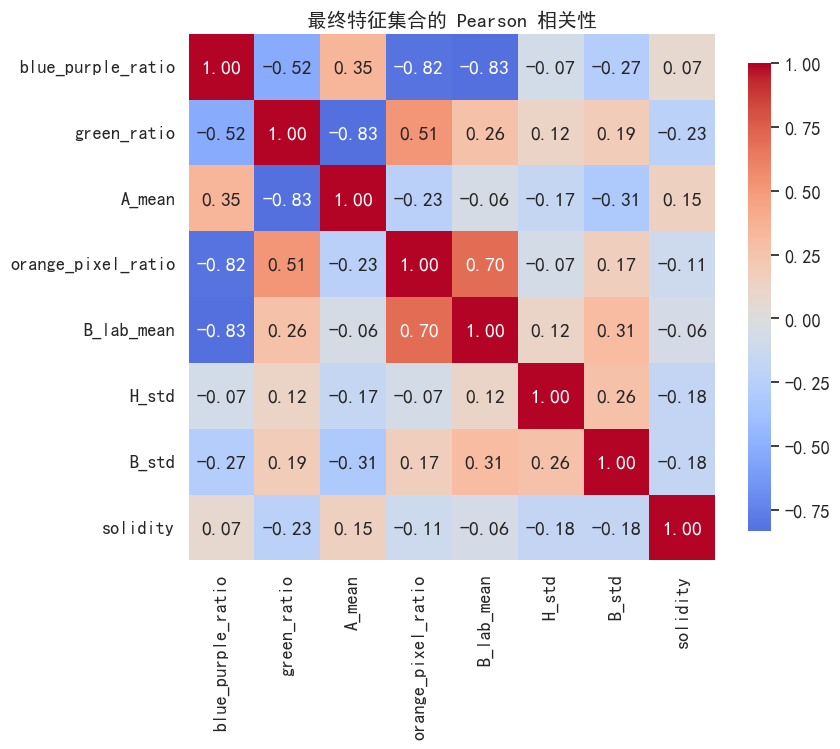

In [18]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    average_precision_score
)

# ------------------------------------------------------------
# 5.1 定义相关性去冗余函数
# ------------------------------------------------------------

def remove_high_corr_features_by_score(feature_list, df_feat, df_scores, threshold=0.90):
    """
    按综合得分排序后的 feature_list 依次遍历。
    如果当前特征与已保留特征高度相关，则删除当前特征。
    
    这样做的含义是：
    - 高排名特征优先保留；
    - 与高排名特征高度重复的低排名特征被删除；
    - 保证最终特征集合既有较强判别力，也不过度冗余。
    """
    selected = []
    removed_pairs = []

    for feat in feature_list:
        keep = True

        for kept_feat in selected:
            r = df_feat[[feat, kept_feat]].corr(method='pearson').iloc[0, 1]

            if abs(r) >= threshold:
                keep = False
                removed_pairs.append({
                    'removed_feature': feat,
                    'kept_feature': kept_feat,
                    'corr': r
                })
                break

        if keep:
            selected.append(feat)

    return selected, pd.DataFrame(removed_pairs)


# ------------------------------------------------------------
# 5.2 准备标签、分组和候选特征数量
# ------------------------------------------------------------

X_all = df_feat.copy()
y = np.array(labels)

# base_id 用于防止增强图像泄漏
groups = df_meta_valid['base_id'].values

# 候选 Top-k 数量
k_list = [5, 8, 10, 12, 15, 20, 25, 30]

# 最多不能超过当前特征数
k_list = [k for k in k_list if k <= len(df_scores)]

results = []

# 尽量使用 StratifiedGroupKFold；
# 如果 sklearn 版本不支持或数据不适合，则退回 GroupKFold。
try:
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    use_stratified_group = True
except Exception:
    cv = GroupKFold(n_splits=5)
    use_stratified_group = False

print("交叉验证方式：", "StratifiedGroupKFold" if use_stratified_group else "GroupKFold")


# ------------------------------------------------------------
# 5.3 遍历不同 Top-k 特征数量，并进行交叉验证
# ------------------------------------------------------------

for k in k_list:
    # 先按照综合得分取 Top-k
    ranked_feats = df_scores.head(k)['feature'].tolist()

    # 再进行相关性去冗余
    selected_feats, removed_corr_pairs = remove_high_corr_features_by_score(
        ranked_feats,
        df_feat=X_all,
        df_scores=df_scores,
        threshold=0.90
    )

    X_k = X_all[selected_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

    auc_list = []
    bacc_list = []
    f1_list = []
    pr_auc_list = []

    if use_stratified_group:
        split_iter = cv.split(X_k, y, groups)
    else:
        split_iter = cv.split(X_k, y, groups)

    for train_idx, test_idx in split_iter:
        X_train, X_test = X_k.iloc[train_idx], X_k.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(
                class_weight='balanced',
                max_iter=3000,
                solver='liblinear',
                random_state=42
            ))
        ])

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        # 某些极端折中可能只有一个类别，AUC 会报错，因此做保护
        try:
            auc = roc_auc_score(y_test, y_prob)
        except ValueError:
            auc = np.nan

        try:
            pr_auc = average_precision_score(y_test, y_prob)
        except ValueError:
            pr_auc = np.nan

        auc_list.append(auc)
        pr_auc_list.append(pr_auc)
        bacc_list.append(balanced_accuracy_score(y_test, y_pred))
        f1_list.append(f1_score(y_test, y_pred, zero_division=0))

    results.append({
        'top_k_input': k,
        'n_after_corr_filter': len(selected_feats),
        'selected_features': selected_feats,
        'auc_mean': np.nanmean(auc_list),
        'auc_std': np.nanstd(auc_list),
        'bacc_mean': np.nanmean(bacc_list),
        'bacc_std': np.nanstd(bacc_list),
        'f1_mean': np.nanmean(f1_list),
        'f1_std': np.nanstd(f1_list),
        'pr_auc_mean': np.nanmean(pr_auc_list),
        'pr_auc_std': np.nanstd(pr_auc_list)
    })

df_k = pd.DataFrame(results)


# ------------------------------------------------------------
# 5.4 可视化：不同特征数量下的模型性能
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.errorbar(
    df_k['n_after_corr_filter'],
    df_k['auc_mean'],
    yerr=df_k['auc_std'],
    marker='o',
    capsize=4,
    label='ROC-AUC'
)

plt.errorbar(
    df_k['n_after_corr_filter'],
    df_k['bacc_mean'],
    yerr=df_k['bacc_std'],
    marker='s',
    capsize=4,
    label='Balanced Accuracy'
)

plt.errorbar(
    df_k['n_after_corr_filter'],
    df_k['f1_mean'],
    yerr=df_k['f1_std'],
    marker='^',
    capsize=4,
    label='F1-score'
)

plt.errorbar(
    df_k['n_after_corr_filter'],
    df_k['pr_auc_mean'],
    yerr=df_k['pr_auc_std'],
    marker='D',
    capsize=4,
    label='PR-AUC'
)

plt.xlabel('去冗余后的特征数量')
plt.ylabel('交叉验证性能')
plt.title('不同特征数量下的分类性能变化')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5.5 自动选择最终特征数量
# ------------------------------------------------------------
#
# 选择原则：
# 1. 先找到 ROC-AUC 最高的方案；
# 2. 在 AUC 距离最高值不超过 0.01 的方案中，
#    选择特征数量最少的方案；
# 3. 这样可以避免为了极小的性能提升而加入过多特征。

best_auc = df_k['auc_mean'].max()
auc_tolerance = 0.01

candidate_rows = df_k[df_k['auc_mean'] >= best_auc - auc_tolerance].copy()

# 优先选择特征更少的方案
candidate_rows = candidate_rows.sort_values(
    by=['n_after_corr_filter', 'auc_mean'],
    ascending=[True, False]
)

best_row = candidate_rows.iloc[0]

final_n_features = int(best_row['n_after_corr_filter'])
final_features_auto = best_row['selected_features']

print("=" * 70)
print("最终特征数量选择结果")
print("=" * 70)
print(f"最高平均 ROC-AUC：{best_auc:.4f}")
print(f"允许的 AUC 容忍范围：{auc_tolerance:.4f}")
print(f"最终选择的去冗余后特征数量：{final_n_features}")
print(f"该方案平均 ROC-AUC：{best_row['auc_mean']:.4f} ± {best_row['auc_std']:.4f}")
print(f"该方案 Balanced Accuracy：{best_row['bacc_mean']:.4f} ± {best_row['bacc_std']:.4f}")
print(f"该方案 F1-score：{best_row['f1_mean']:.4f} ± {best_row['f1_std']:.4f}")
print(f"该方案 PR-AUC：{best_row['pr_auc_mean']:.4f} ± {best_row['pr_auc_std']:.4f}")

print("\n最终确定的特征如下：")
for i, feat in enumerate(final_features_auto, 1):
    print(f"{i:02d}. {feat}")


# ------------------------------------------------------------
# 5.6 可视化：最终特征的综合得分
# ------------------------------------------------------------

final_score_df = df_scores[df_scores['feature'].isin(final_features_auto)].copy()

# 保持最终特征的顺序
final_score_df['feature'] = pd.Categorical(
    final_score_df['feature'],
    categories=final_features_auto,
    ordered=True
)

final_score_df = final_score_df.sort_values('feature')

plt.figure(figsize=(8, max(4, 0.35 * len(final_features_auto))))

plt.barh(
    final_score_df['feature'],
    final_score_df['composite_score']
)

plt.xlabel('综合得分')
plt.ylabel('最终入选特征')
plt.title('最终入选特征的综合得分')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5.7 可视化：最终特征相关性热力图
# ------------------------------------------------------------

plt.figure(figsize=(0.6 * final_n_features + 4, 0.6 * final_n_features + 3))

corr_final = X_all[final_features_auto].corr(method='pearson')

sns.heatmap(
    corr_final,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('最终特征集合的 Pearson 相关性')
plt.tight_layout()
plt.show()